In [1]:
import torch
import torchvision 
import torch.nn as nn
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#hyper parameters
input_size = 784
hidden_size = 256
num_classes = 10
num_epochs = 2
batch_size = 64
learning_rate = 0.001

## MNIST dataset

In [3]:
# from torchvision import datasets
#from torchvision.transforms import ToTensor
training_data = datasets.MNIST(
    root = './data',
    train = True ,
    transform = ToTensor(),
    download = True
)

testing_data = datasets.MNIST(
    root = './data',
    train = False ,
    transform = ToTensor()
)

## Data Loader

In [4]:
# from torch.utils.data import DataLoader
train_loader = DataLoader(
    training_data,
    batch_size = batch_size, # 64
    shuffle = True
)

test_loader = DataLoader(
    testing_data ,
    batch_size = batch_size, # 64
    shuffle = False, # مش هتفرق true من false الاتنين زي بعض 
)

## creat CNN

#### fully connected neural network with one hidden layer (256) using ReLU activation function

In [5]:
# import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size , hidden_size , num_classes):
        super(NeuralNet, self).__init__()
        self.flatten = nn.Flatten()  # علشان اعمل فلاتن للصوره ال هتدخل 
        self.input_size = input_size
        self.l1 = nn.Linear(input_size , hidden_size) # (784 , 256)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size , num_classes) #(256 , 10)

    def forward(self, x):
        x   = self.flatten(x) # لازم تتكتب بردو علشان الفلاتن 
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out

model = NeuralNet(input_size , hidden_size , num_classes).to(device)
# علشان اخلي المودل يشتعلي علي ال Gpu 

## loss & optimizer

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [7]:
model = model.to(device)

## model traning (training loop)

In [8]:
n_total_steps = len(train_loader)
model.train() # علشان اخلي الموديل في وضع التدريب 

for epoch in range(num_epochs):
    for i, (images , labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        #forward pass 
        output = model(images)
        loss = criterion(output , labels) #calculate loss btw output & labels

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'epoch[{epoch+1}/{num_epochs}], step[{i+1}/{n_total_steps}], loss: {loss.item():.4f}')
            

epoch[1/2], step[100/938], loss: 0.5891
epoch[1/2], step[200/938], loss: 0.4095
epoch[1/2], step[300/938], loss: 0.1876
epoch[1/2], step[400/938], loss: 0.2756
epoch[1/2], step[500/938], loss: 0.4083
epoch[1/2], step[600/938], loss: 0.1792
epoch[1/2], step[700/938], loss: 0.2482
epoch[1/2], step[800/938], loss: 0.1719
epoch[1/2], step[900/938], loss: 0.1493
epoch[2/2], step[100/938], loss: 0.1102
epoch[2/2], step[200/938], loss: 0.1049
epoch[2/2], step[300/938], loss: 0.0894
epoch[2/2], step[400/938], loss: 0.0980
epoch[2/2], step[500/938], loss: 0.0990
epoch[2/2], step[600/938], loss: 0.0515
epoch[2/2], step[700/938], loss: 0.1014
epoch[2/2], step[800/938], loss: 0.0998
epoch[2/2], step[900/938], loss: 0.1061


## Model evaluation (Testing phase)

In [9]:
model.eval()
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images , labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)

        _, predicted = torch.max(output , 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

    acc = 100.0* n_correct/n_samples 
    print(f'Accurcy of network = {acc} %')
    

Accurcy of network = 96.87 %


## Visualization

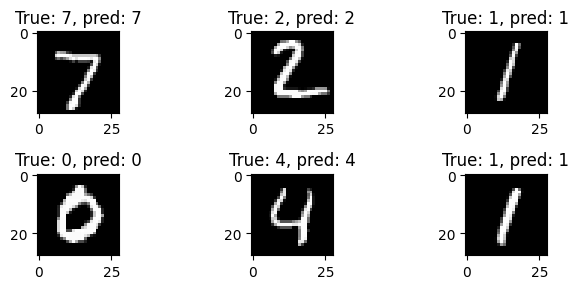

In [10]:
import matplotlib.pyplot as plt 
model.eval()
with torch.no_grad():
    example = enumerate(test_loader)
    batch_index , (example_data, example_target) = next(example)

    output = model(example_data.to(device))
    _, preds = torch.max(output, 1)

    plt.figure(figsize=(7, 3))
    for i in range (6):
        plt.subplot(2, 3, i+1)
        plt.tight_layout()
        plt.imshow(example_data[i][0], cmap = 'gray', interpolation = 'none')
        plt.title(f'True: {example_target[i].item()}, pred: {preds[i].item()}')
        plt.xticks()
        plt.yticks()
    plt.show()